In [1]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx


In [2]:
# Load NHGIS block data
nhgis = pd.read_csv("nhgis0002_ds258_2020_block.csv", dtype=str)

# Keep only what we need
nhgis = nhgis[[
    "GEOCODE",        # Block GEOID
    "INTPTLAT",       # centroid lat
    "INTPTLON",       # centroid lon
    "U7H001"          # population
]].copy()

# Rename to consistent names
nhgis.rename(columns={
    "GEOCODE": "BLOCK_GEOID20",
    "U7H001": "population"
}, inplace=True)

# Convert numeric fields
nhgis["population"] = nhgis["population"].astype(float)

# INTPTLAT / INTPTLON are strings like "+42.6692483"
nhgis["INTPTLAT"] = nhgis["INTPTLAT"].astype(float)
nhgis["INTPTLON"] = nhgis["INTPTLON"].astype(float)

# IMPORTANT: from_xy(LON, LAT)
gdf_blocks = gpd.GeoDataFrame(
    nhgis,
    geometry=gpd.points_from_xy(
        nhgis["INTPTLON"],
        nhgis["INTPTLAT"]
    ),
    crs="EPSG:4326"
)

# Project for distance calculations
gdf_blocks = gdf_blocks.to_crs(32618)

# Tompkins = 36109, Schuyler = 36097
gdf_blocks = gdf_blocks[
    gdf_blocks["BLOCK_GEOID20"].str.startswith(("36109", "36097"))
].reset_index(drop=True)

In [3]:
tompkins_poverty = pd.read_csv("blocks.csv", dtype=str)

tompkins_poverty = tompkins_poverty[[
    "BLOCK_GEOID20", "poverty_rate_est"
]].copy()

tompkins_poverty["BLOCK_GEOID20"] = tompkins_poverty["BLOCK_GEOID20"].astype(str)
tompkins_poverty["poverty_rate_est"] = tompkins_poverty["poverty_rate_est"].astype(float) / 100.0

In [4]:
gdf_blocks = gdf_blocks.merge(
    tompkins_poverty,
    on="BLOCK_GEOID20",
    how="left"
)

In [5]:
SCHUYLER_POVERTY_RATE = 0.151  

In [6]:
gdf_blocks["county_fips"] = gdf_blocks["BLOCK_GEOID20"].str[2:5]
def assign_poverty(row):
    if row["county_fips"] == "109":   # Tompkins
        return row["poverty_rate_est"]
    elif row["county_fips"] == "097": # Schuyler
        return SCHUYLER_POVERTY_RATE
    else:
        return np.nan

gdf_blocks["poverty_frac_final"] = gdf_blocks.apply(assign_poverty, axis=1)
gdf_blocks_new = gdf_blocks.copy()
gdf_blocks_old = gdf_blocks.copy()

In [7]:
gdf_blocks.head()

,BLOCK_GEOID20,INTPTLAT,INTPTLON,population,geometry,poverty_rate_est,county_fips,poverty_frac_final
0,360979501001000,42.543094,-76.702852,11.0,POINT (360177.539 4711483.33),NaN,097,0.151
1,360979501001001,42.542990,-76.714519,17.0,POINT (359219.302 4711491.06),NaN,097,0.151
2,360979501001002,42.540524,-76.723426,40.0,POINT (358482.376 4711232.122),NaN,097,0.151
3,360979501001003,42.538836,-76.730203,5.0,POINT (357922.053 4711056.012),NaN,097,0.151
4,360979501001004,42.541794,-76.740613,3.0,POINT (357073.922 4711401.946),NaN,097,0.151


In [8]:
pantries_new = pd.read_csv("pantries_new.csv")
gdf_pantry_new = gpd.GeoDataFrame(pantries_new,geometry=gpd.points_from_xy(pantries_new.Long, pantries_new.Lat),crs="EPSG:4326").to_crs(32618)
pantry_ids_new = gdf_pantry_new["Pantry"].tolist()
gdf_pantry_new["lot_norm"] = gdf_pantry_new["lot_acres"] / gdf_pantry_new["lot_acres"].mean()

pantries_old = pd.read_csv("pantries_old.csv")
gdf_pantry_old = gpd.GeoDataFrame(pantries_old,geometry=gpd.points_from_xy(pantries_old.Long, pantries_old.Lat),crs="EPSG:4326").to_crs(32618)
pantry_ids_old = gdf_pantry_old["Pantry"].tolist()
gdf_pantry_old["lot_norm"] = gdf_pantry_old["lot_acres"] / gdf_pantry_old["lot_acres"].mean()

In [9]:
decay_rate = 0.765  # 23.5% drop per mile

def decay(d_miles):
    return decay_rate ** d_miles

alpha = 1.0   # decay influence
beta  = 0.2   # lot size influence (tunable)

def make_attraction(id,table,base):
    for pid in id:
        pantry_row = table.loc[table["Pantry"] == pid].iloc[0]
        pantry_point = pantry_row.geometry
        lot_norm = pantry_row["lot_norm"]

        # distance in miles from each block to this pantry
        distances = gdf_blocks.geometry.distance(pantry_point) / 1609.34

        # distance decay
        D_ij = decay(distances)

        # attractiveness = distance decay * normalized lot size
        base[f"A_{pid}"] = (D_ij ** alpha) * (lot_norm ** beta)
        
make_attraction(pantry_ids_new,gdf_pantry_new,gdf_blocks_new)
make_attraction(pantry_ids_old,gdf_pantry_old,gdf_blocks_old)


In [10]:
def normalize(id,base):
    A_cols = [f"A_{pid}" for pid in id]
    A_sum = base[A_cols].sum(axis=1)

    for pid in id:
        base[f"P_{pid}"] = base[f"A_{pid}"] / A_sum

normalize(pantry_ids_new,gdf_blocks_new)
normalize(pantry_ids_old,gdf_blocks_old)

In [11]:
def demand(id,base):
    P_cols = [f"P_{pid}" for pid in id]

    w1 = 1.0
    w2 = 0.4
    w3 = 0.2

    base["first_prob_value"]  = base[P_cols].max(axis=1)
    base["second_prob_value"] = base[P_cols].apply(lambda row: row.nlargest(2).iloc[-1], axis=1)
    base["third_prob_value"] = base[P_cols].apply(lambda row: row.nlargest(3).iloc[-1], axis=1)

    base["first_pantry"]  = base[P_cols].idxmax(axis=1)
    base["second_pantry"] = base[P_cols].apply(lambda row: row.nlargest(2).index[-1], axis=1)
    base["third_pantry"]  = base[P_cols].apply(lambda row: row.nlargest(3).index[-1], axis=1)

    for pid in id:
        D1 = base.apply(lambda row: row["first_prob_value"]  if row["first_pantry"]  == f"P_{pid}" else 0, axis=1)
        D2 = base.apply(lambda row: row["second_prob_value"] if row["second_pantry"] == f"P_{pid}" else 0, axis=1)
        D3 = base.apply(lambda row: row["third_prob_value"]  if row["third_pantry"]  == f"P_{pid}" else 0, axis=1)
        
        base[f"demand_{pid}"] = (
            base["population"] * base["poverty_frac_final"] * (w1*D1 + w2*D2 + w3*D3)
        )

demand(pantry_ids_new,gdf_blocks_new)
demand(pantry_ids_old,gdf_blocks_old)

In [12]:
pantry_demand_new = {
    pid: gdf_blocks_new[f"demand_{pid}"].sum()
    for pid in pantry_ids_new
}
pantry_demand_old = {
    pid: gdf_blocks_old[f"demand_{pid}"].sum()
    for pid in pantry_ids_old
}

print(f"Demands with new location: ", pantry_demand_new)
print(f"Demands with old location: ", pantry_demand_old)

Demands with new location:  {'NEW Enfield Food Distribution': 518.7023689219913, 'Tompkins Community Action': 612.4413426114527, 'St. Johns Community Services Pantry': 0.0, 'Ithaca Free Clinic': 5.338642249545898, 'Salvation Army SK- Ithaca Saturday FP': 1609.144614385646, 'Immaculate Conception Food Pantry': 375.8675060508822, 'Baptized Church of Jesus Christ': 0.0, 'Ithaca Kitchen Cupboard': 1448.0660012331336, 'Schyuler Outreach Food Pantry': 102.99693911327756, 'Schyuler County Food Pantry': 106.3460868260902, 'Pantry at Schyuler Hospital': 785.5210455766382, 'Catholic Charities Food Pantry': 110.20051192744371}
Demands with old location:  {'Tompkins Community Action': 749.0516150444523, 'St. Johns Community Services Pantry': 0.0, 'Ithaca Free Clinic': 6.960979392746019, 'Salvation Army SK- Ithaca Saturday FP': 1763.5129246700642, 'Immaculate Conception Food Pantry': 405.6448820260406, 'Baptized Church of Jesus Christ': 0.0, 'Enfield Food Distribution': 297.5890522790286, 'Ithaca K

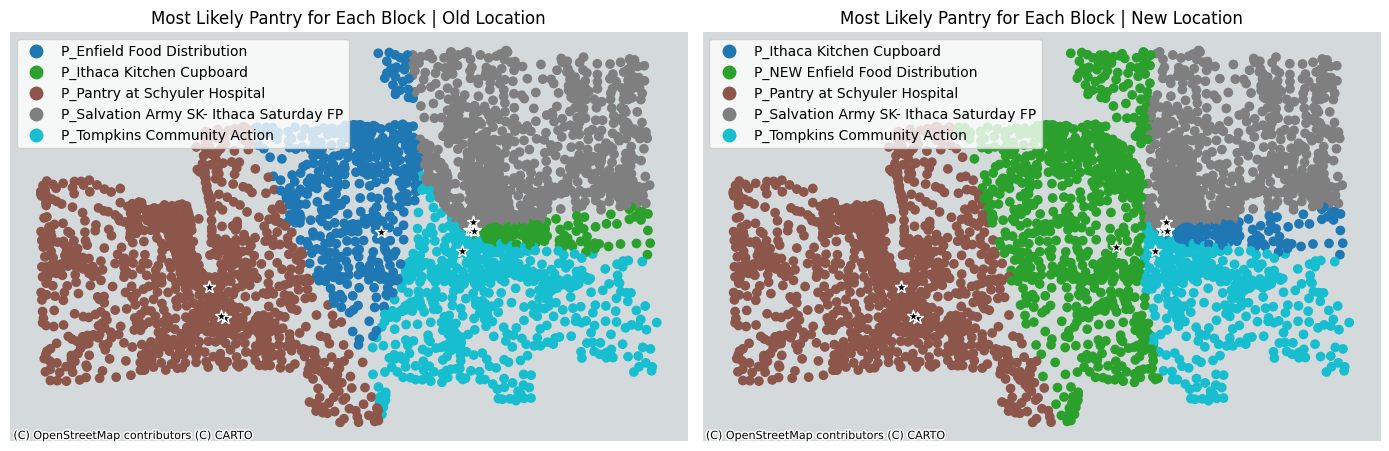

In [13]:
# Assign best pantry
gdf_blocks_new["best_pantry"] = gdf_blocks_new[[f"P_{pid}" for pid in pantry_ids_new]].idxmax(axis=1)
gdf_blocks_old["best_pantry"] = gdf_blocks_old[[f"P_{pid}" for pid in pantry_ids_old]].idxmax(axis=1)

# Create side-by-side figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- NEW LOCATION MAP ---
gdf_blocks_new.plot(
    column="best_pantry",
    cmap="tab10",
    legend=True,
    ax=ax2
)
ax2.set_title("Most Likely Pantry for Each Block | New Location")

# Overlay pantry locations (NEW)
gdf_pantry_new.plot(
    ax=ax2,
    marker="*",
    color="black",
    markersize=80,
    edgecolor="white"
)

# Remove axis ticks/labels
ax2.set_axis_off()


# --- OLD LOCATION MAP ---
gdf_blocks_old.plot(
    column="best_pantry",
    cmap="tab10",
    legend=True,
    ax=ax1
)
ax1.set_title("Most Likely Pantry for Each Block | Old Location")

# Overlay pantry locations (OLD)
gdf_pantry_old.plot(
    ax=ax1,
    marker="*",
    color="black",
    markersize=80,
    edgecolor="white"
)

ctx.add_basemap(ax1, source=ctx.providers.CartoDB.Positron)
ctx.add_basemap(ax2, source=ctx.providers.CartoDB.Positron)

# Remove axis ticks/labels
ax1.set_axis_off()

plt.tight_layout()
plt.show()


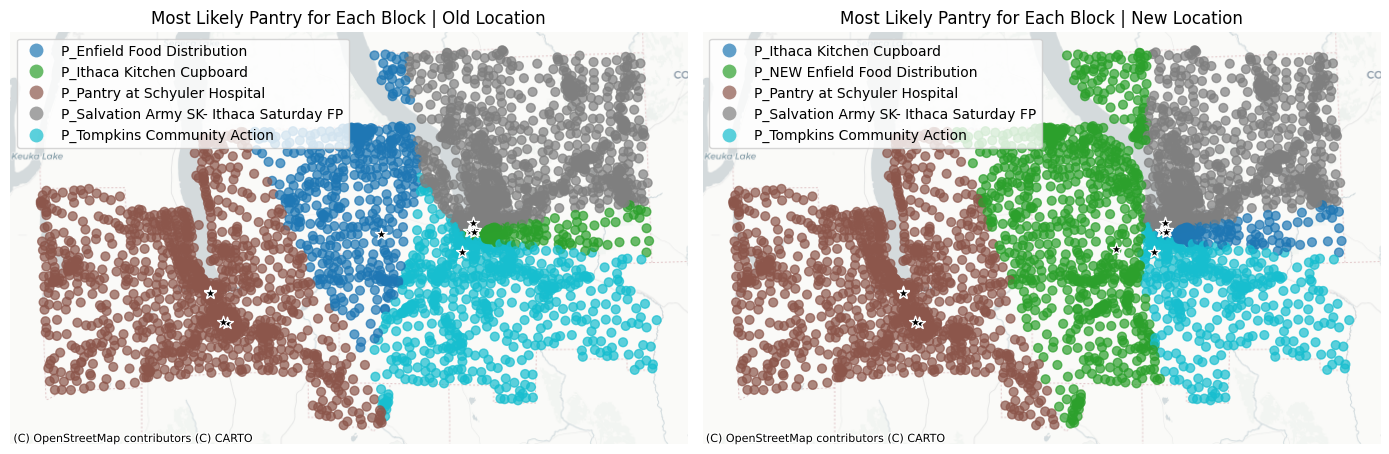

In [16]:
# Reproject to Web Mercator for contextily
gdf_blocks_new_3857 = gdf_blocks_new.to_crs(epsg=3857)
gdf_blocks_old_3857 = gdf_blocks_old.to_crs(epsg=3857)
gdf_pantry_new_3857 = gdf_pantry_new.to_crs(epsg=3857)
gdf_pantry_old_3857 = gdf_pantry_old.to_crs(epsg=3857)

# Assign best pantry
gdf_blocks_new_3857["best_pantry"] = gdf_blocks_new_3857[[f"P_{pid}" for pid in pantry_ids_new]].idxmax(axis=1)
gdf_blocks_old_3857["best_pantry"] = gdf_blocks_old_3857[[f"P_{pid}" for pid in pantry_ids_old]].idxmax(axis=1)

# Create side-by-side figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- OLD LOCATION MAP ---
gdf_blocks_old_3857.plot(
    column="best_pantry",
    cmap="tab10",
    legend=True,
    ax=ax1,
    alpha=0.7,
    zorder=2,
    markersize=40,
)
gdf_pantry_old_3857.plot(
    ax=ax1,
    marker="*",
    color="black",
    markersize=80,
    edgecolor="white",
    zorder=3
)
ctx.add_basemap(ax1, source=ctx.providers.CartoDB.Positron, zoom='auto')
ax1.set_title("Most Likely Pantry for Each Block | Old Location")
ax1.set_axis_off()

# --- NEW LOCATION MAP ---
gdf_blocks_new_3857.plot(
    column="best_pantry",
    cmap="tab10",
    legend=True,
    ax=ax2,
    alpha=0.7,
    zorder=2,
    markersize=40,
)
gdf_pantry_new_3857.plot(
    ax=ax2,
    marker="*",
    color="black",
    markersize=80,
    edgecolor="white",
    zorder=3
)
ctx.add_basemap(ax2, source=ctx.providers.CartoDB.Positron, zoom='auto')
ax2.set_title("Most Likely Pantry for Each Block | New Location")
ax2.set_axis_off()

plt.tight_layout()
plt.show()

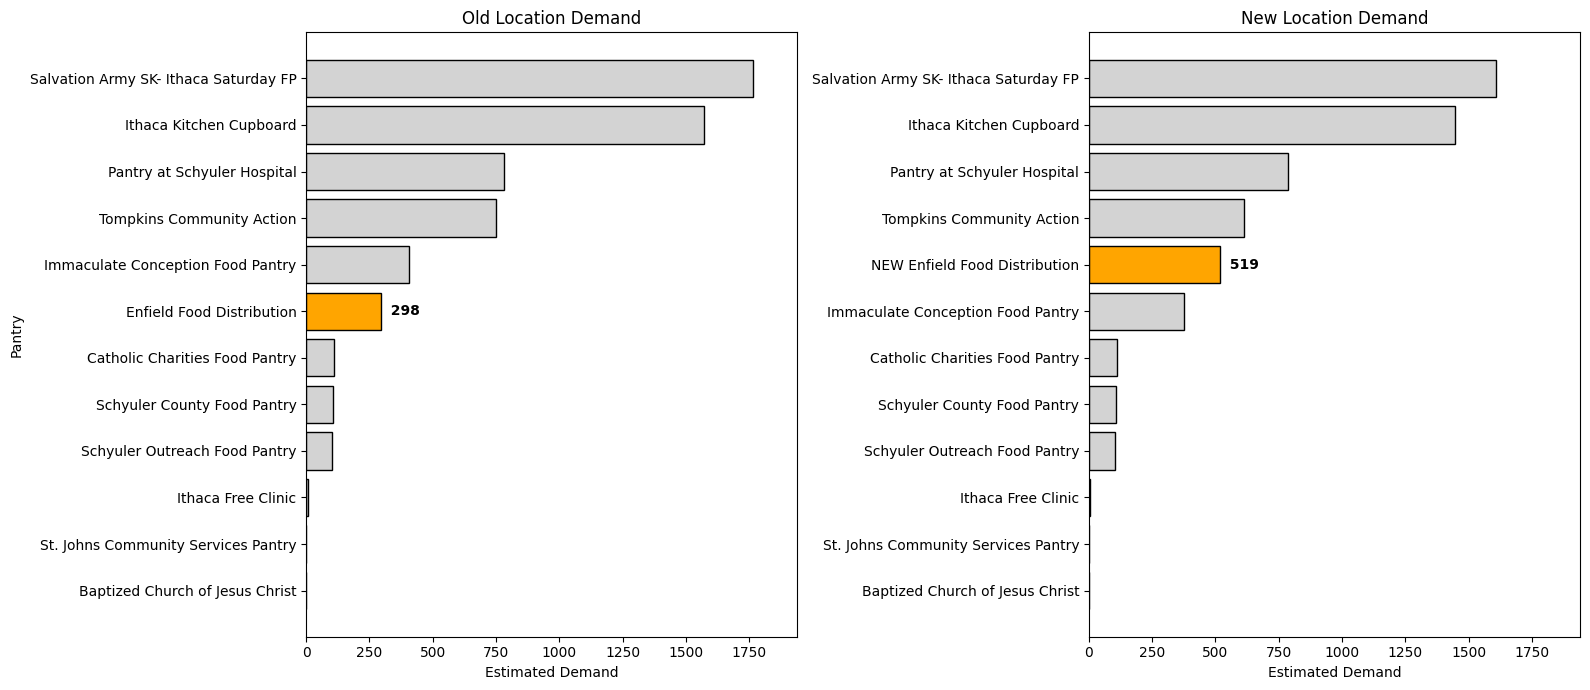

In [14]:
# --- SORT OLD ---
sorted_items_old = sorted(pantry_demand_old.items(), key=lambda kv: kv[1], reverse=True)
pantry_names_old = [name for name, val in sorted_items_old]
demand_values_old = [val for name, val in sorted_items_old]

# --- SORT NEW ---
sorted_items_new = sorted(pantry_demand_new.items(), key=lambda kv: kv[1], reverse=True)
pantry_names_new = [name for name, val in sorted_items_new]
demand_values_new = [val for name, val in sorted_items_new]

# Highlight targets
highlight_name1 = "Enfield Food Distribution"
highlight_name2 = "NEW Enfield Food Distribution"

# --- COLORS OLD ---
colors_old = [
    "orange" if name == highlight_name1 else "lightgray"
    for name in pantry_names_old
]

# --- COLORS NEW ---
colors_new = [
    "orange" if name == highlight_name2 else "lightgray"
    for name in pantry_names_new
]

# --- CREATE SIDE-BY-SIDE FIGURE ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharex=True)

# ----- OLD (LEFT) -----
ax1.barh(pantry_names_old, demand_values_old, color=colors_old, edgecolor="black")
ax1.set_title(f"Old Location Demand")
ax1.set_xlabel("Estimated Demand")
ax1.set_ylabel("Pantry")
ax1.invert_yaxis()

# ----- NEW (RIGHT) -----
ax2.barh(pantry_names_new, demand_values_new, color=colors_new, edgecolor="black")
ax2.set_title(f"New Location Demand")
ax2.set_xlabel("Estimated Demand")
ax2.invert_yaxis()

# --- OPTIONAL: REMOVE Y-LABELS ON RIGHT TO REDUCE CLUTTER ---
ax2.set_ylabel("")

# --- OPTIONAL: FORCE SAME X SCALE FOR FAIR COMPARISON ---
max_val = max(max(demand_values_old), max(demand_values_new))
ax1.set_xlim(0, max_val * 1.1)
ax2.set_xlim(0, max_val * 1.1)

for ax, names, values in [(ax1, pantry_names_old, demand_values_old),
                          (ax2, pantry_names_new, demand_values_new)]:
    for i, (name, val) in enumerate(zip(names, values)):
        if name in [highlight_name1, highlight_name2]:
            ax.text(val, i, f"  {val:.0f}", va="center", fontweight="bold")

plt.tight_layout()
plt.show()
